# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name: Riya Rose Paul
### Date: 30/09/2026

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [7]:
import pandas as pd
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [4]:
# TODO: shape, dtypes, missing value summary
df.shape

(48895, 16)

In [5]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [6]:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [9]:
# TODO: check for values that are technically present but don't make real-world sense
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [11]:
# TODO: duplicate check
df.duplicated().sum()

np.int64(0)

**Written notes — what did you find, and what looks suspicious?**

1. The dataset contains some values that are technically present but may not make real-world sense.
2. A price of 0 is suspicious because an Airbnb listing would normally have a positive price.
3. A minimum stay of more than 3 years (1,095 days) is highly unusual and should be checked.
4. Negative values for number_of_reviews or reviews_per_month would also be invalid.

These issues are not missing values, so .isnull() will not detect them.





---
## Part 2 — Missing Value Diagnosis & Treatment

In [12]:
# TODO: investigate missingness pattern(s) across columns

df.isnull().any(axis=0)



,0
id,False
name,True
host_id,False
host_name,True
neighbourhood_group,False
neighbourhood,False
latitude,False
longitude,False
room_type,False
price,False


**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

The missing values in name and host_name are classified as MAR because their missingness may depend on observable listing or host information. last_review and reviews_per_month are classified as MNAR because they are missing when there are no reviews (number_of_reviews = 0). Other columns have no missing values.So i.m going to drop the column last_review because more than 20% are missing. Missing value in reviews_per_month are gonna be replaced by 0

In [13]:
# TODO: apply your chosen treatment(s)
df=df.drop(['last_review','id','name','host_id','host_name'],axis=1)


In [14]:
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [15]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

I would drop the columns because they have many missing values, but this may result in losing useful information about recent reviews and popularity.

---
## Part 3 — Outlier Detection & Treatment

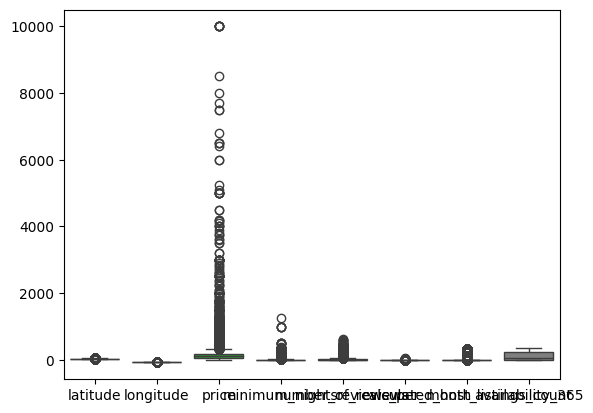

In [16]:
# TODO: detect outliers in at least two numeric columns
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(df)
plt.show()

<Axes: >

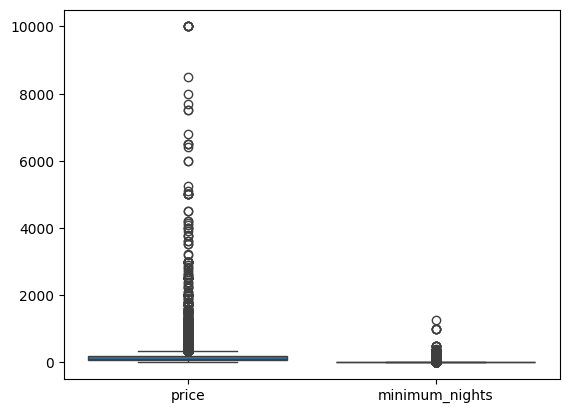

In [17]:
num_cols = ['price','minimum_nights']
sns.boxplot(df[num_cols])

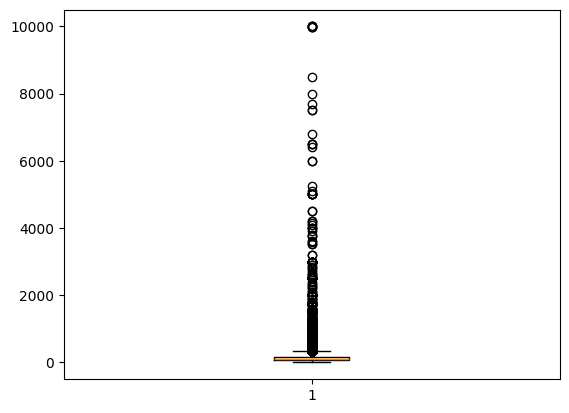

In [18]:
plt.boxplot(df['price'])
plt.show()

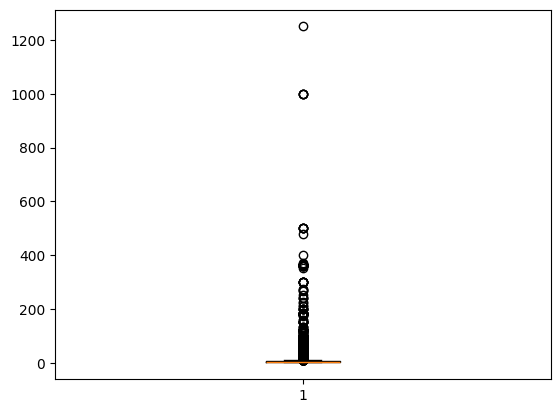

In [19]:
plt.boxplot(df['minimum_nights'])
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

For price, a value of 0 is an error, while values around 10,000 are unusually high but may be genuine luxury listings. I will cap the price between 30 and 2000 to reduce the effect of extreme values. For minimum nights, I will cap the outliers at the lower and upper limits to retain the data while reducing the impact of extreme values.

In [20]:
# TODO: apply treatment consistent with your judgment above
# price

df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

#minimum_nights
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

iqr = q3 - q1

up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

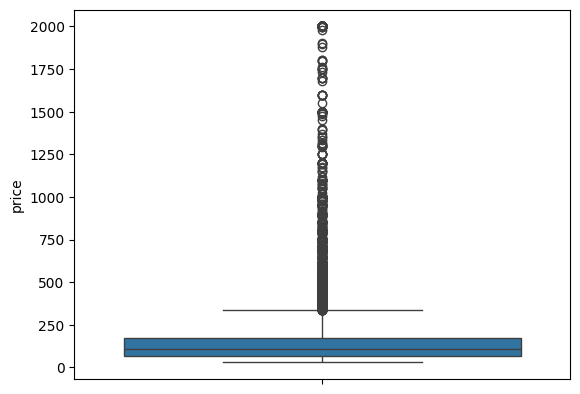

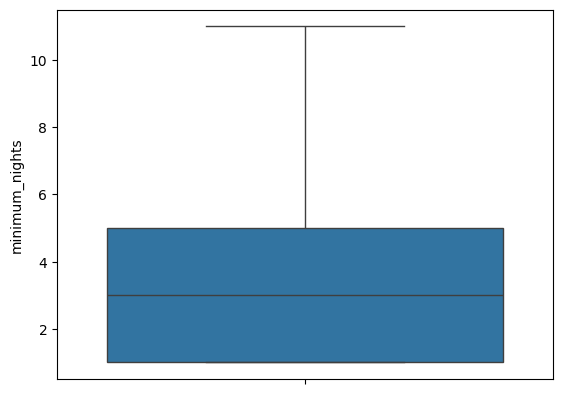

In [21]:
sns.boxplot(df['price'])
plt.show()
sns.boxplot(df['minimum_nights'])
plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


In [23]:
# TODO: encode categorical columns appropriately
df['neighbourhood'].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

In [24]:
frequency = df['neighbourhood'].value_counts()
df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [25]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,175,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,1545,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,2658,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,572,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,1117,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [26]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [27]:
# TODO: engineer at least two new features
from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder(
    categories=[['Shared room', 'Private room', 'Entire home/apt']]
)
df['room_type']=encoder.fit_transform(df[['room_type']])

In [28]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [29]:
df=pd.get_dummies(df,prefix='group',dtype='int',drop_first=True)

In [30]:
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,group_Brooklyn,group_Manhattan,group_Queens,group_Staten Island
0,175,40.64749,-73.97237,1.0,149,1,9,0.21,6,365,1,0,0,0
1,1545,40.75362,-73.98377,2.0,225,1,45,0.38,2,355,0,1,0,0
2,2658,40.80902,-73.94190,1.0,150,3,0,0.00,1,365,0,1,0,0
3,572,40.68514,-73.95976,2.0,89,1,270,4.64,1,194,1,0,0,0
4,1117,40.79851,-73.94399,2.0,80,10,9,0.10,1,0,0,1,0,0


In [31]:
df=df.drop(['latitude','longitude'],axis =1)

**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

The first four columns—id, name, host_id, and host_name—were dropped because they are not needed for prediction. latitude and longitude were also removed because they are not required for this ML model. The categorical columns were handled using suitable encoding methods: neighbourhood was frequency encoded, room_type was ordinal encoded, and neighbourhood_group one-hot encoding is done.

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [33]:
# TODO: train/test split (before fitting anything)


In [34]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [35]:
# TODO: build Pipeline combining your cleaning, imputation, encoding, scaling steps
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()
# Missing value handling & removing unnecessary columns
df=df.drop(['last_review','id','name','host_id','host_name','latitude','longitude'],axis=1)
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [36]:
# Outlier Management
df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

iqr = q3 - q1

up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

Encoding

In [37]:
# neighbourhood - frequency encoding

frequency = df['neighbourhood'].value_counts()
df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [39]:
#X and Y
x = df.drop('price',axis=1)
y = df['price']

# Train_test split
x_train,x_test,y_train,y_test =train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [40]:
numerical_columns = ['neighbourhood','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
nominal_columns = ['neighbourhood_group']
ordinal_columns = ['room_type']

In [41]:
numerical_pipeline = Pipeline([
    ('scalar',StandardScaler())
])

In [42]:
nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

In [43]:
ordinal_pipeline = Pipeline([
    ('encoder',OrdinalEncoder(
        categories=[['Shared room', 'Private room', 'Entire home/apt']]
    ))
])

In [44]:
# Combine Pipelines
preprocessor = ColumnTransformer([
    ('numeric',numerical_pipeline,numerical_columns),
    ('nominal',nominal_pipeline,nominal_columns),
    ('ordinal', ordinal_pipeline, ordinal_columns)
])

In [45]:
# fit and transform training data
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

In [46]:
x_train.shape

(39116, 8)

---
## Part 6 — Written Reflection

1. Dropping last_review may affect the analysis because it can remove useful information about recent reviews and popularity.

2. For live data, we would need to regularly update outlier handling, missing value detection, and frequency encoding.

3. Since many rows contain missing values, deleting them would result in significant data loss.